# 1. Setup

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 2. Load Cleveland Dataset

In [2]:
# https://drive.google.com/file/d/1U02zDTnnSG2Xf_YINxs-FqfR7UbdjeNI/view
!gdown 1U02zDTnnSG2Xf_YINxs-FqfR7UbdjeNI

Downloading...
From: https://drive.google.com/uc?id=1U02zDTnnSG2Xf_YINxs-FqfR7UbdjeNI
To: /content/[Data]-cleveland.csv
100% 10.9k/10.9k [00:00<00:00, 14.4MB/s]


In [3]:
COLUMNS = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

raw = pd.read_csv('[Data]-cleveland.csv', header=None)
raw.columns = COLUMNS

for c in ['age','trestbps','chol','thalach','oldpeak','ca','thal']:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

raw['target'] = (raw['target'] > 0).astype(int)

numeric_cols = ['age','trestbps','chol','thalach','oldpeak']
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

display(raw.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Train / Val / Test Split

In [4]:
X_all = raw.drop(columns=['target'])
y_all = raw['target']

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

print(len(X_train), len(X_val), len(X_test))

242 30 31


## 4. Feature Engineering Pipeline

In [5]:
class AddNewFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_age_bins=5): self.n_age_bins = n_age_bins

    def fit(self, X, y=None):
        self.columns_ = list(X.columns)
        age = pd.to_numeric(X['age'], errors='coerce').dropna()
        _, edges = pd.cut(age, bins=self.n_age_bins, labels=False,
                          retbins=True, duplicates='drop')
        edges[0], edges[-1] = -np.inf, np.inf
        self.age_bin_edges_ = edges
        self.new_features_ = ['chol_per_age','bps_per_age','hr_ratio','age_bin']
        return self

    def transform(self, X):
        Xdf = X.copy()
        Xdf['chol_per_age'] = Xdf['chol'] / Xdf['age']
        Xdf['bps_per_age'] = Xdf['trestbps'] / Xdf['age']
        Xdf['hr_ratio'] = Xdf['thalach'] / Xdf['age']
        Xdf['age_bin'] = pd.cut(Xdf['age'], bins=self.age_bin_edges_,
                                labels=False, include_lowest=True).astype('category')
        return Xdf

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.columns_ + self.new_features_, dtype=object)

all_nums = numeric_cols + ['chol_per_age','bps_per_age','hr_ratio']
all_cats = categorical_cols + ['age_bin']

cat_proc = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('onehot', OneHotEncoder(handle_unknown='ignore',
                                              sparse_output=False))])
num_proc = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])

preprocess = ColumnTransformer([
    ('num', num_proc, all_nums),
    ('cat', cat_proc, all_cats),
], verbose_feature_names_out=False).set_output(transform='pandas')

fe_pipeline = Pipeline([
    ('add_features', AddNewFeaturesTransformer(n_age_bins=5)),
    ('preprocess', preprocess)
]).set_output(transform='pandas')

Xt_train = fe_pipeline.fit_transform(X_train, y_train)
Xt_train = Xt_train[Xt_train.columns[Xt_train.nunique() > 1]]

cat_prefixes = tuple(c + '_' for c in all_cats)
is_discrete = np.array([c.startswith(cat_prefixes) for c in Xt_train.columns])

print("Columns after one-hot:", Xt_train.shape[1])

Columns after one-hot: 36


## 5. Rank and Compare the Two Criteria

In [6]:
dt = DecisionTreeClassifier(random_state=SEED).fit(Xt_train, y_train)
fi = pd.Series(dt.feature_importances_, index=Xt_train.columns)

mi = pd.Series(mutual_info_classif(Xt_train.values, y_train.values,
                                   discrete_features=is_discrete,
                                   random_state=SEED),
               index=Xt_train.columns)

fi_top = set(fi.nlargest(10).index)
mi_top = set(mi.nlargest(10).index)

print("Only in FI :", sorted(fi_top - mi_top))
print("Only in MI :", sorted(mi_top - fi_top))
print("Shared features:", len(fi_top & mi_top))

Only in FI : ['age', 'chol_per_age', 'cp_3.0', 'hr_ratio']
Only in MI : ['exang_1.0', 'slope_1.0', 'slope_2.0', 'thal_7.0']
Shared features: 6


## 6. Visualization

,FI,MI
1,thal_3.0,thal_3.0
2,cp_4.0,thal_7.0
3,ca_0.0,cp_4.0
4,chol_per_age,ca_0.0
5,hr_ratio,exang_0.0
6,oldpeak,exang_1.0
7,chol,oldpeak
8,age,slope_1.0
9,exang_0.0,chol
10,cp_3.0,slope_2.0


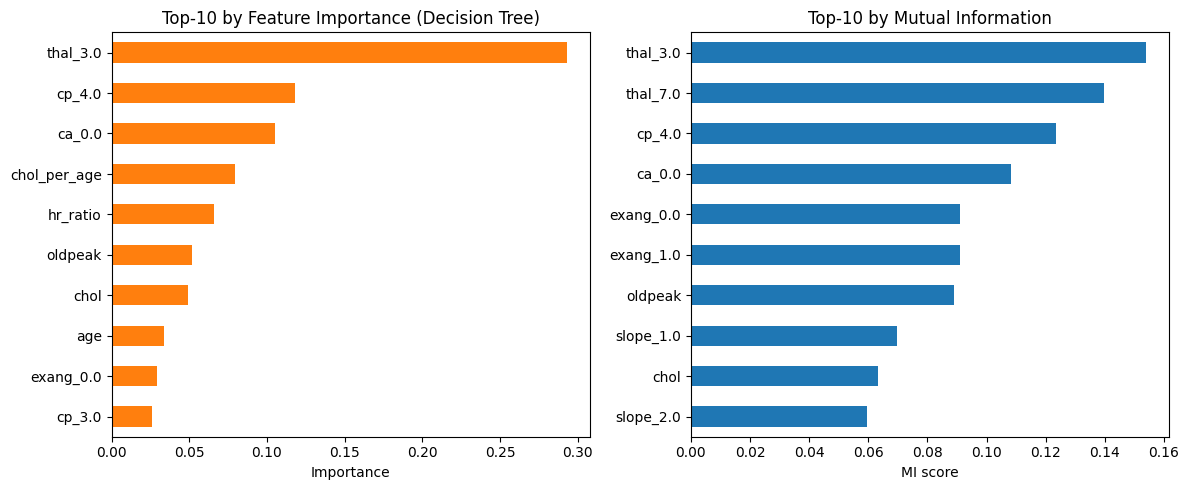

In [7]:
display(pd.DataFrame({'FI': fi.nlargest(10).index, 'MI': mi.nlargest(10).index},
                     index=range(1, 11)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fi.nlargest(10).iloc[::-1].plot.barh(ax=axes[0], color='tab:orange')
axes[0].set_title('Top-10 by Feature Importance (Decision Tree)')
axes[0].set_xlabel('Importance')

mi.nlargest(10).iloc[::-1].plot.barh(ax=axes[1], color='tab:blue')
axes[1].set_title('Top-10 by Mutual Information')
axes[1].set_xlabel('MI score')

plt.tight_layout()
plt.show()